In [7]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import networkx as nx
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import BrainAreas, RSA, load_img_natraster, print_wise, TimeSeries, get_relevant_output_layers
from general_utils.dRSA import across_areas_dRSA
from general_utils.II import InformationImbalance, compare_similarity_metrics

In [64]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'baby1'
    date: str = '220226to527' # '250313' #  #  # # "230204"#'240816to26'
    brain_area: str = 'AIT'
    new_fs: int = 100 # Hz
    k=1
    RDM_metric1 = 'euclidean'
    RDM_metric2 = 'cosine_cnt'
    metrics = ["euclidean", "cosine_cnt", "magnitude_diff", "correlation"]
    model_name: str = 'vit_l_16'
    layer_name: str = 'blocks.16.mlp.fc2'
    img_size: int = 384
    pooling: str = 'mean'
    pkg: str = 'timm'

cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
brain_areas = ['V1', 'V2', 'V3', 'PIT', 'CIT', 'AIT']

In [65]:
def load_and_plot_II(paths, cfg, i_mt, j_mt, idx, l, ax, ncols, color):
    save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{cfg.k}_{i_mt}-{j_mt}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{cfg.k}_{i_mt}-{j_mt}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    A2B = np.load(save_name_A2B)["arr_0"]
    B2A = np.load(save_name_B2A)["arr_0"]
    ax.set_title(l, fontsize=12)
    ax_right = ax.twinx()
    l_m1, = ax_right.plot(
        A2B,
        color=color,
        linestyle="--",
        linewidth=2,
    )
    
    l_m2, = ax_right.plot(
        B2A,
        color=color,
        linestyle="-",
        linewidth=2,
    )
    ax.spines["left"].set_linewidth(2.5)
    color = "tab:blue"
    ax.spines["left"].set_color(color)
    ax.tick_params(axis="y", colors=color)
    ax.yaxis.label.set_color(color)

    color = "tab:red"
    ax_right.spines["right"].set_color(color)
    ax_right.tick_params(axis="y", colors=color)
    ax_right.yaxis.label.set_color(color)
    
    ax_right.spines["right"].set_linewidth(2.5)
    ax_right.set_ylim([.4, 1.05])
    if idx % ncols != ncols - 1:
        ax_right.set_yticks([.4, .6, .8, 1.0])
        ax_right.set_yticklabels([])
        ax_right.set_ylabel("")
    else:
        ax_right.tick_params(axis='both', labelsize=15)
    return l_m1, l_m2, A2B


def plot_metrics_II(paths, layers, cfg, ylim = None, save=False, colors=["tab:blue", "tab:cyan", "mediumseagreen", "tab:green"]):
    n_layers = len(layers)
    ncols = 4
    nrows = int(np.ceil(n_layers / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4*ncols, 3*nrows),
        sharex=True, sharey=True
    )
    axes = axes.flatten()
    

    for idx, (ax, l) in enumerate(zip(axes, layers)):
        handles = []
        labels = []
        counter = 0
        for i_mt in [cfg.RDM_metric1,cfg.RDM_metric2]:  
            for j_mt in [cfg.RDM_metric1,cfg.RDM_metric2]:  
                l_m_A2B, l_m_B2A, ii = load_and_plot_II(paths, cfg, i_mt, j_mt, idx, l, ax, ncols, colors[counter]) 
                counter +=1
                handles.append(l_m_A2B)
                handles.append(l_m_B2A)
                labels.append(f"neural->model {i_mt}-{j_mt} ")
                labels.append(f"model->neural {i_mt}-{j_mt}")

    # remove unused axes
    for ax in axes[len(layers):]:
        ax.axis("off")

    fig.supxlabel("Time from image onset (ms)", fontsize=20)
    fig.supylabel("RSA Similarity", fontsize=20, color='tab:blue')
    fig.suptitle(f"Brain area: {cfg.brain_area}", fontsize=27)
    fig.tight_layout()

    fig.legend(handles, labels,fontsize=12, bbox_to_anchor=(0.98, 0.90))
    # make space on the right for the legend
    fig.tight_layout(rect=[0.03, 0, 0.80, .97])
    fig.text(
        0.85, 0.5,                  # x, y in figure coordinates
        "Information Imbalance",
        va="center",
        ha="right",
        rotation=-90,
        fontsize=20,
        color='tab:red'
    )
    # ax.set_xticks(xtickspos)           # positions of ticks
    # ax.set_xticklabels([int(xt*1000/cfg.new_fs) for xt in xtickspos], fontsize=15)
    if ylim is not None:
        for ax in axes[:n_layers]:
            ax.set_ylim(ylim[0], ylim[1])
    xtickspos = range(0, len(ii)+1, 10)       
    for ax in axes[:n_layers]:  # only the used axes
        ax.set_xticks(xtickspos)
        ax.set_xticklabels([int(xt*1000/cfg.new_fs) for xt in xtickspos], fontsize=15)
        ax.tick_params(axis='both', labelsize=15)
        # ax_right = ax.twinx()
        # ax_right.tick_params(axis='right', labelsize=15)
    if save==True:
        return fig, axes
    else:
        plt.show()


def plot_metrics_II_2(paths, layers, cfg, ylim = None, save=False, colors=["tab:blue", "tab:cyan", "mediumseagreen", "tab:green"]):
    n_layers = len(layers)
    ncols = 4
    nrows = int(np.ceil(n_layers / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4*ncols, 3*nrows),
        sharex=True, sharey=True
    )
    axes = axes.flatten()
    

    for idx, (ax, l) in enumerate(zip(axes, layers)):
        handles = []
        labels = []
        counter = 0
        for i_mt in [cfg.RDM_metric1,cfg.RDM_metric2]:  
            l_m_A2B, l_m_B2A, ii = load_and_plot_II(paths, cfg, i_mt, i_mt, idx, l, ax, ncols, colors[counter]) 
            counter +=1
            handles.append(l_m_A2B)
            handles.append(l_m_B2A)
            labels.append(f"neural->model {i_mt}-{i_mt} ")
            labels.append(f"model->neural {i_mt}-{i_mt}")

    # remove unused axes
    for ax in axes[len(layers):]:
        ax.axis("off")

    fig.supxlabel("Time from image onset (ms)", fontsize=20)
    fig.supylabel("RSA Similarity", fontsize=20, color='tab:blue')
    fig.suptitle(f"Brain area: {cfg.brain_area}", fontsize=27)
    fig.tight_layout()

    fig.legend(handles, labels,fontsize=12, bbox_to_anchor=(0.98, 0.90))
    # make space on the right for the legend
    fig.tight_layout(rect=[0.03, 0, 0.80, .97])
    fig.text(
        0.85, 0.5,                  # x, y in figure coordinates
        "Information Imbalance",
        va="center",
        ha="right",
        rotation=-90,
        fontsize=20,
        color='tab:red'
    )
    # ax.set_xticks(xtickspos)           # positions of ticks
    # ax.set_xticklabels([int(xt*1000/cfg.new_fs) for xt in xtickspos], fontsize=15)
    if ylim is not None:
        for ax in axes[:n_layers]:
            ax.set_ylim(ylim[0], ylim[1])
    xtickspos = range(0, len(ii)+1, 10)       
    for ax in axes[:n_layers]:  # only the used axes
        ax.set_xticks(xtickspos)
        ax.set_xticklabels([int(xt*1000/cfg.new_fs) for xt in xtickspos], fontsize=15)
        ax.tick_params(axis='both', labelsize=15)
        # ax_right = ax.twinx()
        # ax_right.tick_params(axis='right', labelsize=15)
    if save==True:
        return fig, axes
    else:
        plt.show()


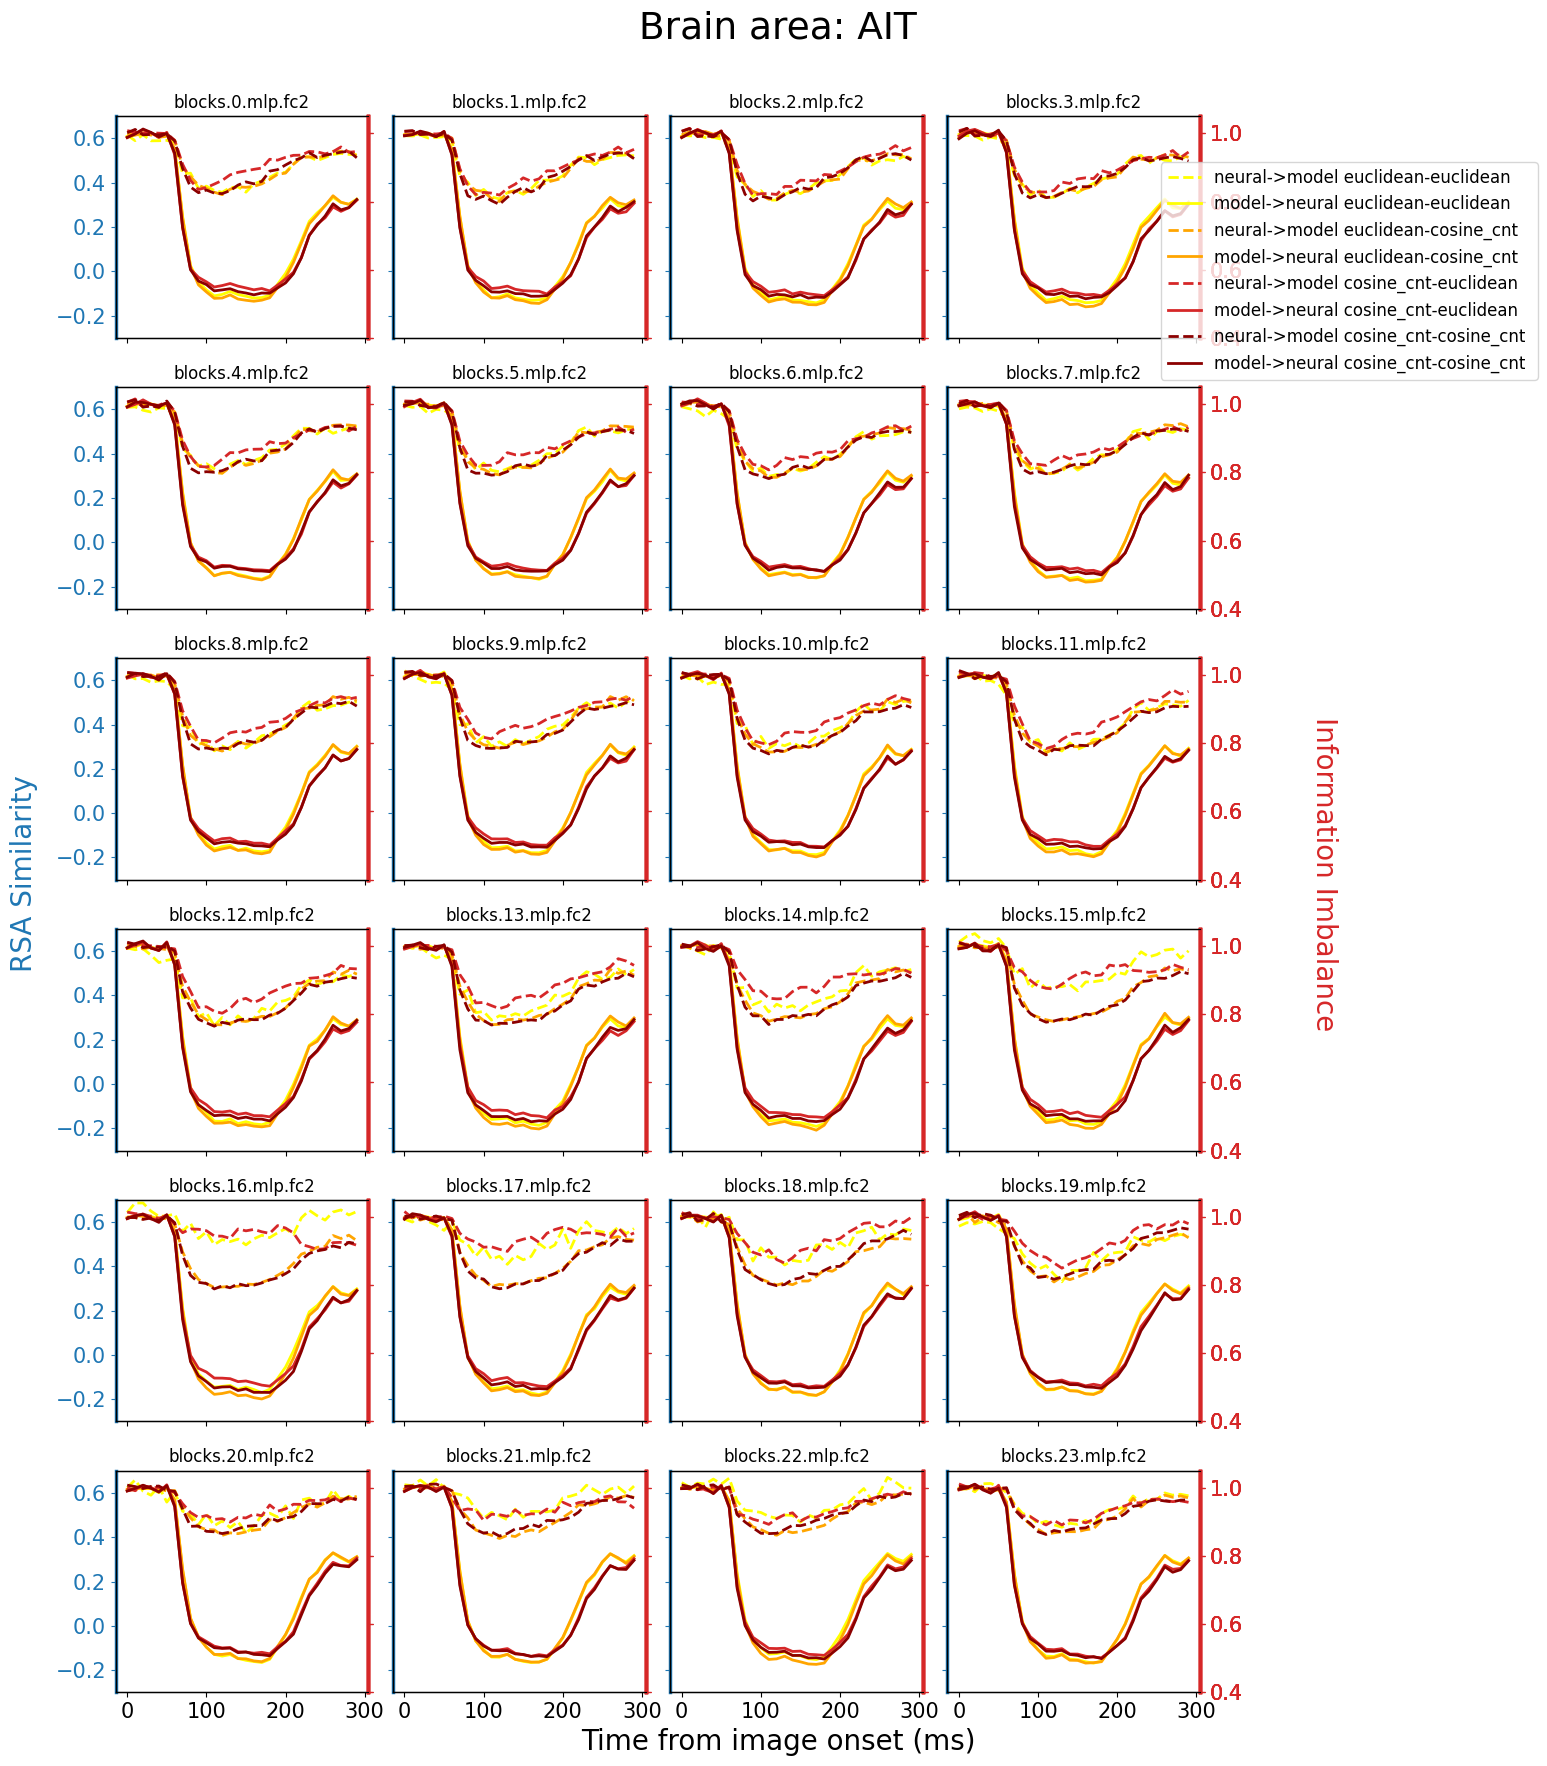

In [66]:
plot_metrics_II(paths, layers, cfg, ylim=[-.3, .7], colors= ["darkred", "tab:red", "orange", "yellow"][::-1])

In [8]:
target_metric = "euclidean"; comparing_metric = "correlation"; 


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{target_metric}-{comparing_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{comparing_metric}-{target_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
A2B = np.load(save_name_A2B)["arr_0"]
B2A = np.load(save_name_B2A)["arr_0"]

In [ ]:
import matplotlib.pyplot as plt

from matplotlib.patches import FancyArrowPatch
import numpy as np
from matplotlib.patches import FancyArrowPatch
import numpy as np

def draw_directed_edge(ax, p0, p1, alpha,
                       color="k", lw=1, arrow_scale=15):
    """
    Draw a straight edge p0 -> p1 with:
    - full line always present
    - arrowhead positioned at alpha along the line
    """
    p0 = np.asarray(p0)
    p1 = np.asarray(p1)

    # 1) full supporting line
    ax.plot(
        [p0[0], p1[0]],
        [p0[1], p1[1]],
        color=color,
        linewidth=lw,
        zorder=1,
    )

    # 2) arrowhead placed along the line
    direction = p1 - p0
    direction /= np.linalg.norm(direction)

    point = p0 + alpha * (p1 - p0)

    arrow = FancyArrowPatch(
        point - 1e-3 * direction,   # minimal shaft → always visible
        point,
        arrowstyle='-|>',
        mutation_scale=arrow_scale,
        linewidth=lw,
        color=color,
        zorder=2
    )
    ax.add_patch(arrow)


In [30]:
for monkey_name, date in zip(["three0"],["250313"]): #zip(["paul", "baby1", "red", "three0"],["230204", "220226to527", "220227", "250313"]):
    print(f"\n\n{monkey_name}" )
    for i, target_metric in enumerate(cfg.metrics):
        for j, comparing_metric in enumerate(cfg.metrics):
            if i != j:
                save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{target_metric}-{comparing_metric}_{monkey_name}_{date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
                save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{comparing_metric}-{target_metric}_{monkey_name}_{date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
                A2B = np.max(np.load(save_name_A2B)["arr_0"])
                B2A = np.max(np.load(save_name_B2A)["arr_0"])
                print(target_metric, comparing_metric, f"\nA2B {A2B}", f"B2A {B2A}\n")

informativeness = np.log(1 / weights)
inf_norm = (informativeness - informativeness.min()) / \
           (informativeness.max() - informativeness.min())



three0
euclidean cosine_cnt 
A2B 0.008127192050164737 B2A 0.03412291423105537

euclidean magnitude_diff 
A2B 1.0345380752471038 B2A 0.9813609310234882

euclidean correlation 
A2B 0.016134817727707515 B2A 0.18450751939632268

cosine_cnt euclidean 
A2B 0.03412291423105537 B2A 0.008127192050164737

cosine_cnt magnitude_diff 
A2B 1.0200672228717187 B2A 1.0305259591880116

cosine_cnt correlation 
A2B 0.010080109469656711 B2A 0.10532468912743119

magnitude_diff euclidean 
A2B 0.9813609310234882 B2A 1.0345380752471038

magnitude_diff cosine_cnt 
A2B 1.0305259591880116 B2A 1.0200672228717187

magnitude_diff correlation 
A2B 1.0356473854819854 B2A 1.0134943936656393

correlation euclidean 
A2B 0.18450751939632268 B2A 0.016134817727707515

correlation cosine_cnt 
A2B 0.10532468912743119 B2A 0.010080109469656711

correlation magnitude_diff 
A2B 1.0134943936656393 B2A 1.0356473854819854



NameError: name 'weights' is not defined

In [31]:
G = nx.DiGraph()
tot_sum = 0
for i, target_metric in enumerate(cfg.metrics):
    for j, comparing_metric in enumerate(cfg.metrics):
        if i != j:
            save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{target_metric}-{comparing_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
            # A2B = (1 - np.max(np.load(save_name_A2B)["arr_0"]))**2
            A2B = np.log(1/ np.max(np.load(save_name_A2B)["arr_0"]))
            tot_sum +=A2B
            # print(A2B)
            G.add_edge(target_metric, comparing_metric, weight=A2B)
pos = nx.circular_layout(G)
pos = {node: 0.5 * coord for node, coord in pos.items()}

In [102]:
import matplotlib.colors as mcolors
def draw_parallel_bidirectional_edge(ax, p0, p1, w01, w10,
                                     color="k", alpha=1.0, lw=2,
                                     arrow_scale=20,
                                     separation=0.05,
                                     node_radius=0.15,  
                                     margin=0.02, 
                                     wiggle=0.0):

    p0 = np.asarray(p0)
    p1 = np.asarray(p1)

    vec = p1 - p0
    total_length = np.linalg.norm(vec)
    direction = vec / total_length
    mid = (p0 + p1) / 2

    # usable length between circle borders
    usable_length = total_length - 2 * node_radius - 2 * margin
    usable_length = max(usable_length, 0)

    # perpendicular direction
    perp = np.array([-direction[1], direction[0]])

    # shift midpoint to be between circle borders
    center_segment_start = p0 + direction * (node_radius + margin)
    center_segment_end   = p1 - direction * (node_radius + margin)
    mid = (center_segment_start + center_segment_end) / 2

    # ---- A → B ----
    if w01 > 0:
        factor = np.clip(w01, 0.01, 1.0)
        half_len = factor * usable_length / 2

        start = mid - direction * half_len
        end   = mid + direction * half_len

        # offset = separation * perp
        offset = (separation + wiggle) * perp

        arrow = FancyArrowPatch(
            start + offset,
            end + offset,
            arrowstyle='-|>',
            mutation_scale=arrow_scale,
            linewidth=lw,
            color=color,
            alpha=alpha,
            zorder=2
        )
        ax.add_patch(arrow)

    # ---- B → A ----
    if w10 > 0:
        factor = np.clip(w10, 0.01, 1.0)
        half_len = factor * usable_length / 2

        start = mid + direction * half_len
        end   = mid - direction * half_len

        # offset = -separation * perp
        offset = -(separation + wiggle) * perp
        arrow = FancyArrowPatch(
            start + offset,
            end + offset,
            arrowstyle='-|>',
            mutation_scale=arrow_scale,
            linewidth=lw,
            color=color,
            alpha=alpha,
            zorder=2
        )
        ax.add_patch(arrow)

def get_label_color(color):
    """
    Returns 'white' if color is dark, 'black' if light.
    Accepts: color name (str), RGB tuple, or RGBA tuple
    """
    try:
        # convert string color names to RGB
        rgb = mcolors.to_rgb(color)
    except ValueError:
        # assume it's already a tuple/list
        rgb = color[:3]  # take first 3 values if RGBA

    r, g, b = rgb
    lum = 0.299*r + 0.587*g + 0.114*b
    return 'white' if lum < 0.5 else 'black'


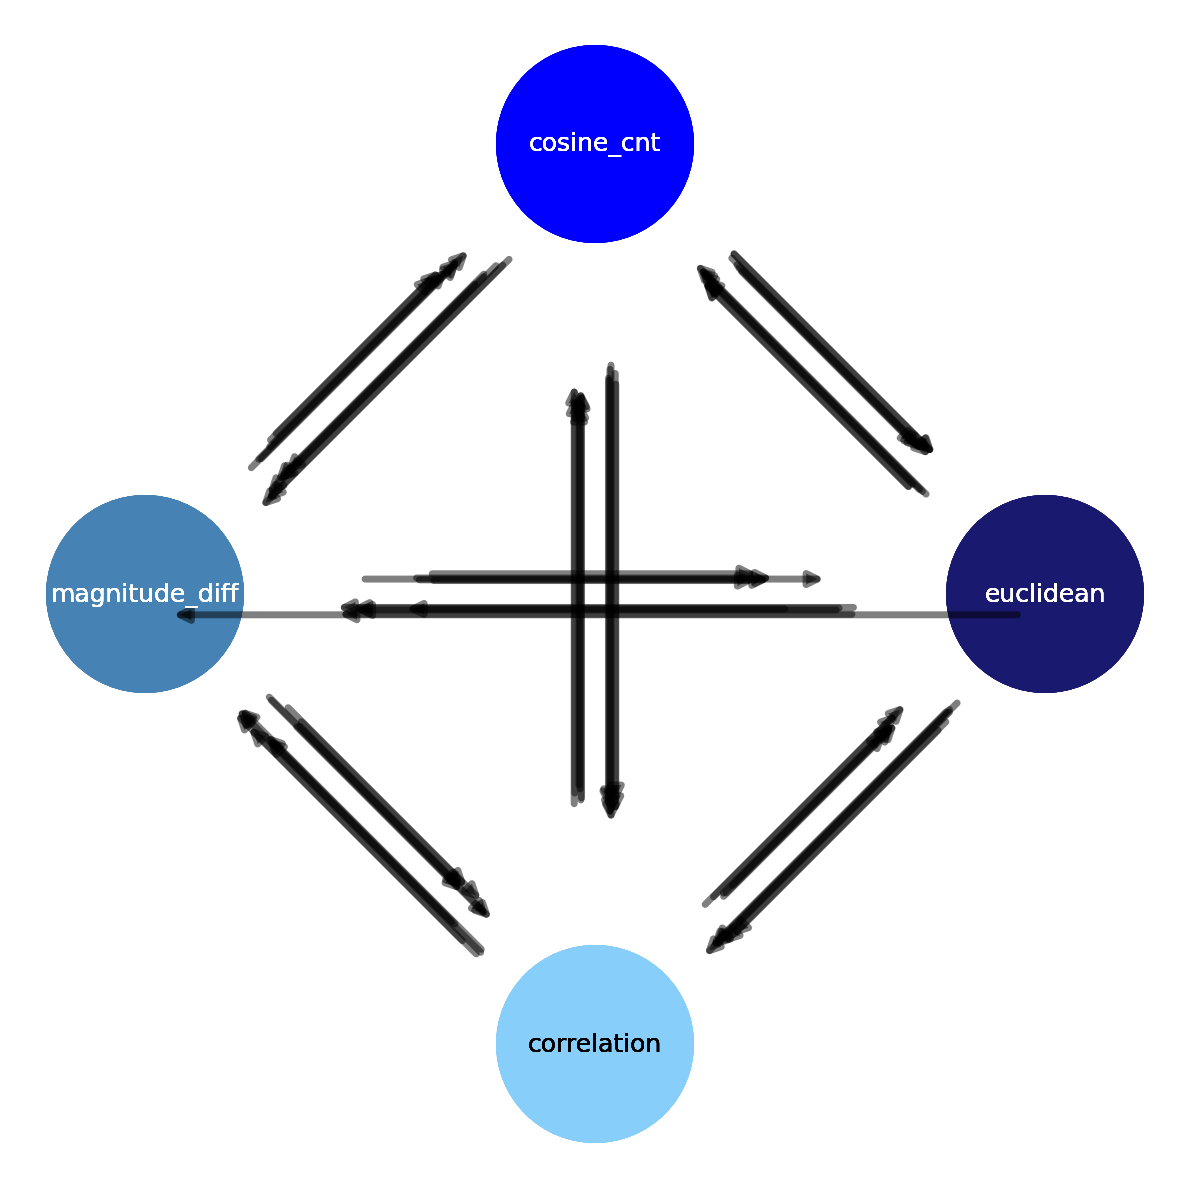

In [103]:
from matplotlib.patches import FancyArrowPatch
from general_utils.plots import truncate_colormap




fig, ax = plt.subplots(figsize=(12,12))
pos = nx.circular_layout(G)

# Larger nodes
# colors = [truncate_colormap(plt.cm.Blues, maxval=.9)(i / (len(cfg.metrics) - 1)) for i in range(len(cfg.metrics))]  # from light to dark
colors= ["midnightblue","blue","steelblue", "lightskyblue",]



label_colors = {node: get_label_color(color) for node, color in zip(G.nodes(), colors)}

# draw nodes

for monkey_name, date in zip(["paul", "baby1",  "three0", "red", "octavius",   "baby1"], ["230204", '220226to527', '250313', '220227', '220227to405',  '240816to26']): #,  'friday',,'220228to327',
# for monkey_name, date in zip(["three0"], ["250313"]):
    G = nx.DiGraph()
    wig = np.random.uniform(0, 0.02)

    for i, target_metric in enumerate(cfg.metrics):
        for j, comparing_metric in enumerate(cfg.metrics):
            if i != j:
                try:
                    save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{target_metric}-{comparing_metric}_{monkey_name}_{date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
                    # A2B = (1 - np.max(np.load(save_name_A2B)["arr_0"]))**2
                    # A2B = np.log(1/ np.max(np.load(save_name_A2B)["arr_0"]))
                    if comparing_metric != "magnitude_diff" and target_metric!="magnitude_diff":
                        A2B = 1- np.max(np.load(save_name_A2B)["arr_0"])
                    else:
                        A2B = 1- np.min(np.load(save_name_A2B)["arr_0"])
                except FileNotFoundError:
                    save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{target_metric}-{comparing_metric}_{monkey_name}_{date}_CIT_{cfg.new_fs}Hz.npz"
                    A2B = 1 - np.max(np.load(save_name_A2B)["arr_0"])
                    # A2B = np.log(1/ np.max(np.load(save_name_A2B)["arr_0"]))
                
                # print(round(A2B, 4))

                G.add_edge(target_metric, comparing_metric, weight=A2B)

    pos = nx.circular_layout(G)
    pos = {node: 0.5 * coord for node, coord in pos.items()}
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=20000)
    # draw labels individually
    for node, (x, y) in pos.items():
        plt.text(
            x, y, str(node),
            color=label_colors[node],
            fontsize=18,
            ha='center',
            va='center'
        )
    drawn_pairs = set()
    for u, v in G.edges():
        pair = tuple(sorted([u, v]))
        if pair in drawn_pairs:
            continue
        drawn_pairs.add(pair)

        w_uv = G[u][v]["weight"] if G.has_edge(u, v) else 0
        w_vu = G[v][u]["weight"] if G.has_edge(v, u) else 0
        # w_vu = w_vu/tot_sum #(w_uv + w_vu)
        # w_uv = w_uv/tot_sum #(w_uv + w_vu)
        # factor = (w_uv + w_vu)/tot_sum 
        
    
        total = w_uv + w_vu
        w_vu = (w_vu/(total))**1
        w_uv = (w_uv/(total))**1
        draw_parallel_bidirectional_edge(
            ax, pos[u], pos[v], w_uv, w_vu,
            node_radius=0.0075,  # Pass the increased radius
            wiggle=wig, 
            alpha=.5,
            separation=0.01,
            lw=5
        )
ax.set_aspect('equal')
ax.axis('off')
ax.margins(0.15)    
plt.tight_layout()
plt.show()

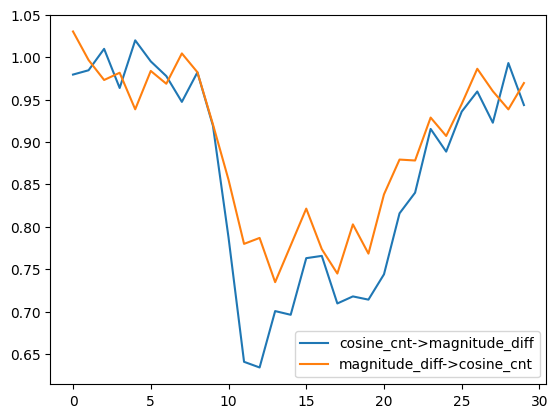

In [99]:

monkey_name = "three0"; date= "250313"
target_metric = "cosine_cnt"
comparing_metric = "magnitude_diff"
save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{target_metric}-{comparing_metric}_{monkey_name}_{date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{comparing_metric}-{target_metric}_{monkey_name}_{date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
# save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_euclidean-magnitude_diff_{monkey_name}_{date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
# save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_magnitude_diff-euclidean_{monkey_name}_{date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
A2B = np.load(save_name_A2B)["arr_0"]
B2A = np.load(save_name_B2A)["arr_0"]
plt.plot(A2B, label=f"{target_metric}->{comparing_metric}")
plt.plot(B2A, label=f"{comparing_metric}->{target_metric}")
plt.legend()

In [230]:
l = cfg.layer_name; i_mt = "euclidean"; j_mt = "euclidean"
save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{cfg.k}_{i_mt}-{j_mt}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{cfg.k}_{i_mt}-{j_mt}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
A2B = 1 - np.min(np.load(save_name_A2B)["arr_0"])
B2A = 1 - np.min(np.load(save_name_B2A)["arr_0"])

In [273]:

def circular_with_center(G, center_node):
    # All nodes except the center
    other_nodes = [n for n in G.nodes if n != center_node]
    
    # Circular layout for the others
    pos = nx.circular_layout(other_nodes)
    
    # Put center node at origin
    pos[center_node] = np.array([0.0, 0.0])
    
    return pos

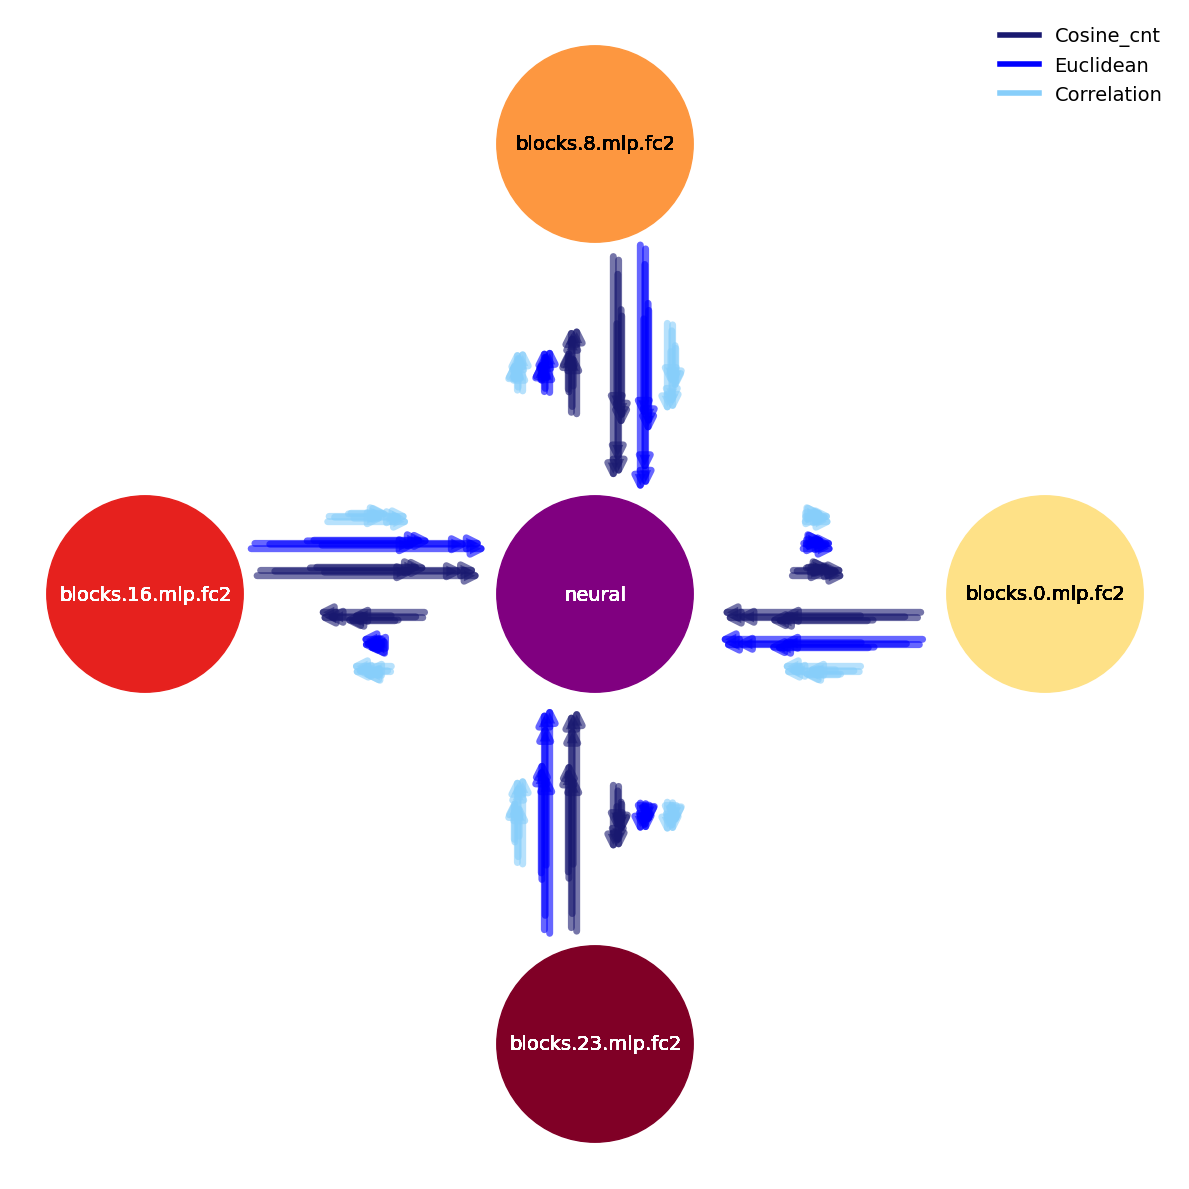

In [353]:
from matplotlib.patches import FancyArrowPatch
from general_utils.plots import truncate_colormap
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
cfg.metric_model = "euclidean"
cfg.metric_neural = "cosine_cnt"
layers = ["blocks.0.mlp.fc2","blocks.8.mlp.fc2", "blocks.16.mlp.fc2", "blocks.23.mlp.fc2"] # get_relevant_output_layers(cfg.model_name, cfg.pkg)#
fig, ax = plt.subplots(figsize=(12,12))
pos = nx.circular_layout(G)

# Larger nodes
# colors = [truncate_colormap(plt.cm.Blues, maxval=.9)(i / (len(cfg.metrics) - 1)) for i in range(len(cfg.metrics))]  # from light to dark
def yellow_red_gradient(n):
    cmap = plt.cm.YlOrRd  # Yellow → Orange → Red
    return [cmap(i) for i in np.linspace(0.2, 1.0, n)]
colors = yellow_red_gradient(len(layers))
colors.insert(0, "purple")



label_colors = {node: get_label_color(color) for node, color in zip(G.nodes(), colors)}

# draw nodes


legend_elements = [
    Line2D([0], [0], color="midnightblue", lw=4, label="Cosine_cnt"),
    Line2D([0], [0], color="blue", lw=4, label="Euclidean"),
    Line2D([0], [0], color="lightskyblue", lw=4, label="Correlation"),
]
G = nx.DiGraph()
# add center node
G.add_node("neural")
# add layer nodes
G.add_nodes_from(layers)
pos = circular_with_center(G, center_node="neural")
pos = {node: 0.5 * coord for node, coord in pos.items()}
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=20000)
for monkey_name, date in zip(['friday', "paul",  "octavius",  "three0", "baby1", "red"], ['220228to327', "230204",   '220227to405',  '250313', '220226to527',  '220227']): #,  , , ,/ baby1, ,'240816to26',
    G = nx.DiGraph()
    wig = np.random.uniform(0, 0.01)

    tot_dict = {l: 0 for l in layers}
    for mt_ij in [("cosine_cnt", "cosine_cnt"), ("euclidean", "euclidean"), ("correlation", "correlation")]:
        for l in layers:
            save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{cfg.k}_{mt_ij[0]}-{mt_ij[1]}_{monkey_name}_{date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
            save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{cfg.k}_{mt_ij[1]}-{mt_ij[0]}_{monkey_name}_{date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
            # A2B = (1 - np.max(np.load(save_name_A2B)["arr_0"]))**2
            A2B = 1- np.min(np.load(save_name_A2B)["arr_0"])
            B2A =1- np.min(np.load(save_name_B2A)["arr_0"])
            tot_dict[l] += A2B
            tot_dict[l] += B2A

    for mt_ij, sep, col in zip([("cosine_cnt", "cosine_cnt"), ("euclidean", "euclidean"), ("correlation", "correlation")], [.02, .05, .08], ["midnightblue","blue","lightskyblue",]):
        for l in layers:
            save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{cfg.k}_{mt_ij[0]}-{mt_ij[1]}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
            save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{cfg.k}_{mt_ij[1]}-{mt_ij[0]}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
            # A2B = (1 - np.max(np.load(save_name_A2B)["arr_0"]))**2
            A2B = 1- np.min(np.load(save_name_A2B)["arr_0"])
            B2A =1- np.min(np.load(save_name_B2A)["arr_0"])
            # print(A2B)
            G.add_edge("neural", l, weight=A2B)
            G.add_edge(l,"neural", weight=B2A)

        # pos = nx.spring_layout(G)
        
        # nx.draw(G, pos, with_labels=True)
        
        # draw labels individually
        for node, (x, y) in pos.items():
            plt.text(
                x, y, str(node),
                color=label_colors[node],
                fontsize=14,
                ha='center',
                va='center'
            )
        drawn_pairs = set()
        for u, v in G.edges():
            pair = tuple(sorted([u, v]))
            if pair in drawn_pairs:
                continue
            drawn_pairs.add(pair)

            w_uv = G[u][v]["weight"] if G.has_edge(u, v) else 0
            w_vu = G[v][u]["weight"] if G.has_edge(v, u) else 0
            # w_vu = w_vu/tot_sum #(w_uv + w_vu)
            # w_uv = w_uv/tot_sum #(w_uv + w_vu)
            # factor = (w_uv + w_vu)/tot_sum 
            total = tot_dict[l]/1.5#w_uv + w_vu
            w_vu = (w_vu/(total))#**1.5
            w_uv = (w_uv/(total))#**1.5
            draw_parallel_bidirectional_edge(
                ax, pos[u], pos[v], w_uv, w_vu,
                node_radius=0.0075,  # Pass the increased radius
                wiggle=wig, 
                alpha=.6, 
                separation=sep,
                color=col, 
                lw=5
            )
        ax.set_aspect('equal')
        ax.axis('off')
        ax.margins(0.15)
        ax.legend(
            handles=legend_elements,
            loc="upper right",
            frameon=False,
            fontsize=14
        )
plt.tight_layout()
plt.show()